# Day 08. Exercise 04
# Regression

## 0. Imports

In [97]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import accuracy_score

warnings.filterwarnings('ignore')
pd.options.display.max_rows = 10

## 1. Preprocessing

1. Read the file [`checker_regression.csv`](https://drive.google.com/file/d/1L8auBzJEghWFewznhhFpcrqxW4GqcfRY/view?usp=sharing).
2. Fill the missing values in it with `0`.
3. Make a split of your dataset on train and test with parameters `test_size=0.2`.

In [98]:
df = pd.read_csv('../data/checker_regression.csv')
df.drop_duplicates(subset='uid', inplace=True)
df.drop('uid', axis=1, inplace=True)
df.fillna(0, inplace=True)
df

,num_commits,pageviews,AVG(diff)
0,62,28.0,0.00
6,20,89.0,0.00
12,7,0.0,-2.00
13,86,0.0,-89.00
14,52,0.0,-48.50
...,...,...,...
72,128,0.0,-104.75
73,40,0.0,-175.60
74,15,0.0,-62.60
75,8,0.0,-115.50


In [99]:
X = df[['num_commits', 'pageviews']]
y = df['AVG(diff)']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)

## 2. Crossvalidation

1. Write a function `crossval` that takes as arguments: `n_splits` for `KFold()`, `X`, `y`, model instantiated class with the parameters of the model (keep in mind: `random_state=21`) and returns for a given model class a result like this:

```
train -  2696.4496895424836   |   test -  1589.9979527104958
train -  2660.957874001452   |   test -  2075.102636027137
train -  2847.315529246795   |   test -  320.911928168403
train -  2500.7691099659237   |   test -  4132.461382030178
train -  2643.927917295123   |   test -  2237.8140952197878
train -  2396.295678819444   |   test -  4509.650064742476
train -  2003.402267924976   |   test -  8403.491474908551
train -  2531.876094212613   |   test -  3135.944102735099
train -  2683.1795186023123   |   test -  1796.01426292594
train -  2537.1192483996338   |   test -  3439.29824116941
Average RMSE on crossval is 3164.0686140637476
```

2. Run the function for `LinearRegression`, `DecisionTreeRegressor`, `RandomForestRegressor`. You may choose the parameters by yourself, but find the good enough for you.

In [ ]:
def crossval(n_splits: int, X: pd.DataFrame, y: pd.DataFrame, model) -> str:
    kf = KFold(n_splits=n_splits, random_state=21, shuffle=True)
    # get split indexes 
    out = ""; rmse_list: list = []
    for train, test in kf.split(X):
        y_train = y.iloc[train]; y_test = y.iloc[test]
        X_train = X.iloc[train]; X_test = X.iloc[test]
        model.fit(X_train, y_train)

        for x_split, y_split, text in ((X_train, y_train, 'train - {:.11f} | '), (X_test, y_test, 'test - {:.11f}\n')):
            predict_col = model.predict(x_split)
            rmse = root_mean_squared_error(y_split, predict_col)
            if text == 'test - {:.11f}\n':
                rmse_list.append(rmse)
            out += text.format(rmse)

    out += f'Average RMSE on crossval is {np.mean(rmse_list):.11f}'

    return out

In [101]:
lin_reg = LinearRegression(fit_intercept=False)
lin_reg_crossval = crossval(10, X, y, lin_reg)
print(lin_reg_crossval)

train - 72.76993808125 | test - 66.00102615432
train - 73.57217751614 | test - 56.93999619800
train - 73.52150368296 | test - 90.18607089189
train - 70.19624500874 | test - 85.93184687247
train - 70.54577537835 | test - 84.88509144096
train - 69.82808185925 | test - 89.03413627285
train - 70.87449516506 | test - 93.48456884028
train - 75.39821241402 | test - 28.36373379691
train - 66.27560430107 | test - 110.26820392379
train - 73.04567124286 | test - 55.39475713286
Average RMSE on crossval is 76.04894315243


In [102]:
dec_tree_class = DecisionTreeRegressor(random_state=42, max_depth=4)
dec_tree_class_crossval = crossval(10, X, y, dec_tree_class)
print(dec_tree_class_crossval)

train - 25.82644531827 | test - 112.90417448323
train - 20.83174087931 | test - 75.34332775394
train - 30.65910625238 | test - 0.00000000000
train - 30.29093011434 | test - 80.50626902206
train - 22.94706936285 | test - 85.74728481121
train - 23.51883939789 | test - 76.68265065865
train - 30.65910625238 | test - 0.00000000000
train - 25.33894664110 | test - 61.15540484427
train - 28.31179227652 | test - 120.86588837737
train - 29.73415849924 | test - 40.58792924011
Average RMSE on crossval is 65.37929291908


In [103]:
random_forest = RandomForestRegressor(random_state=21, max_depth=25, n_estimators=75)
random_forest_crossval = crossval(10, X, y, random_forest)
print(random_forest_crossval)

train - 21.44751189757 | test - 96.43019156264
train - 22.69270002184 | test - 78.15633807252
train - 26.64913361520 | test - 19.95470644238
train - 25.04917067551 | test - 57.85459140381
train - 22.49602359262 | test - 78.50807047650
train - 23.56857307118 | test - 52.26496311283
train - 24.50943337897 | test - 10.27966184773
train - 23.61061151492 | test - 54.68904880814
train - 22.11028287449 | test - 91.58820314183
train - 24.64839968172 | test - 32.69417455416
Average RMSE on crossval is 57.24199494225


## 3. Predictions and evaluation

1. Make predictions for the test dataset using each of the three models with the finalized parameters.
2. Draw a plot for each of the models where the `x-axis` is the actual average difference and the `y-axis` is the prediction made by a model.
3. How would plot look like in the ideal case? Put the answer to the markdown cell in the end of the section.

In [104]:
def plot_act_vs_pred(y_pred, model_name, rmse, acc) -> None:
    to_plot = pd.DataFrame({'actual': y_test, 'prediction': y_pred})
    ax = sns.regplot(data=to_plot, x="actual", y="prediction", ci=15)
    plt.title(f'Actual vs prediction of {model_name} rmse {rmse} acc {acc}')
    plt.show()

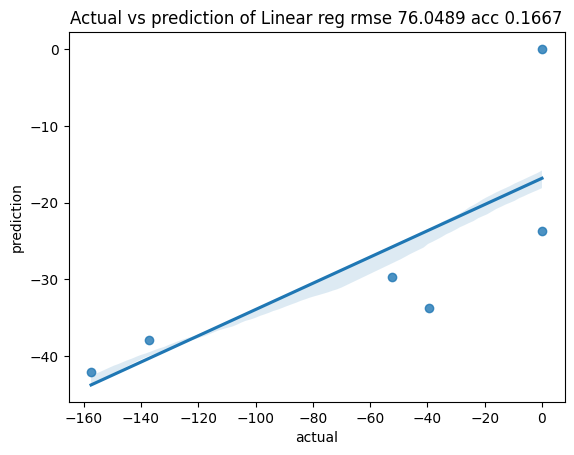

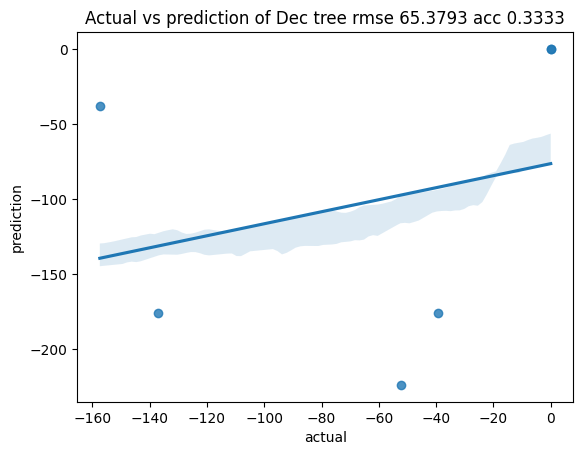

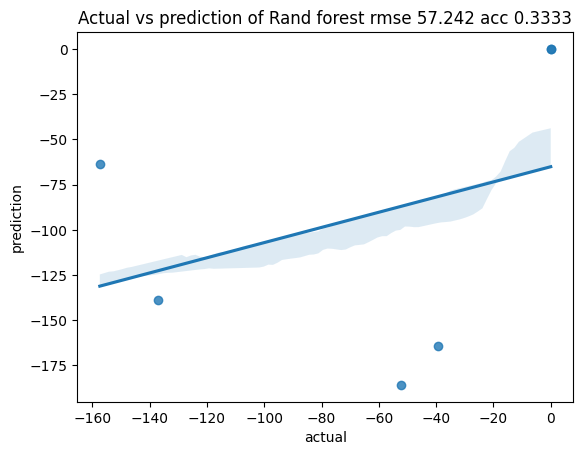

In [105]:
for rmse_model, model, model_name in ((lin_reg_crossval, lin_reg, 'Linear reg'), 
                                      (dec_tree_class_crossval, dec_tree_class, 'Dec tree'), 
                                      (random_forest_crossval, random_forest, 'Rand forest')):

    rmse = rmse_model.rsplit(' ')[-1]
    model.fit(X_train, y_train)
    predict_col = model.predict(X_test)
    acc = accuracy_score(predict_col.astype(int), y_test.astype(int))
    plot_act_vs_pred(predict_col, model_name=model_name, rmse=round(float(rmse), 4), acc=round(acc,4))

How would plot look like in the ideal case?  
Answer: diagonal